# **Note:** This is going to be used as a way to test wether my extraction method actually works before I fully implement it.

In [236]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_year_folders(parent_directory):
    """
    Reads all subdirectories in the parent_directory and returns a list
    of names that appear to be four-digit year folders.

    Args:
        parent_directory (str): The path to the directory containing year folders.

    Returns:
        list: A list of strings, where each string is a year (e.g., "2023").
    """
    p = Path(parent_directory)
    # Use iterdir() to list items and filter for directories
    subdirectories = [x for x in p.iterdir() if x.is_dir()]
    
    year_folders = []
    for subdir in subdirectories:
        # Check if the folder name is a 4-digit number
        if subdir.name.isdigit() and len(subdir.name) == 4:
            year_folders.append(subdir.name)
            
    return year_folders

def create_year_folder(year, output_base="extracted_data"):
    """
    Creates the year folder that I will be extracting my data into."
    """
    output_dir = Path(output_base) / str(year)
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir

def get_date(file_path: str) -> str:
    """
    Extracts date string (YYYY_MM_DD) from a PeMS .txt.gz file path.
    Going to use this as a helper with the extract_file function.
    """
    p = Path(file_path)
    # Remove .gz first
    stem = p.stem  # removes .gz → leaves ...2004_01_01.txt
    # Remove .txt
    stem = Path(stem).stem  # removes .txt
    # Date is last 3 underscore-separated parts
    date_parts = stem.split("_")[-3:]
    return "_".join(date_parts)

def clean_and_label(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans dataframe and computes closure flags.
    Assumes raw PeMS-style columns already present.
    """
    stationIds = [
        3054021, 319677, 319673, 319675, 319680, 319674,
        3411021, 3411024, 3023124, 3023121, 319416, 318690,
        317786, 317791, 317789, 317787, 317788, 317797,
        317798, 3412081, 3412064, 3412061, 3047112, 3047111,
        3047113, 3047108, 3047101, 3412054, 3047097, 3047094,
        3047098, 3047084, 3047085, 3047081, 3047073, 3047072,
        3047075, 3047131, 3047042, 3047043, 314000, 316261,
        316249, 3412041, 316214, 316213, 3038021
    ]
    # Filter stations
    df = df[df["Station"].isin(stationIds)]
    # Timestamp handling
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = df.sort_values(["Station", "Timestamp"])
    # Low flow
    df["low_flow"] = df["Total Flow"] <= 5
    # -----------------
    # OPTION A
    # -----------------
    df["closure_A"] = (
        df.groupby("Station")["low_flow"]
          .transform(lambda s: s.rolling(6, min_periods=6).sum() >= 5)
    )
    # -----------------
    # OPTION B
    # -----------------
    low_counts = df.groupby("Timestamp")["low_flow"].sum()
    multi_station_low = low_counts >= 2

    closure_B_times = (
        multi_station_low
            .rolling(3, min_periods=3)
            .sum() == 3
    )
    df["closure_B"] = (
        df["Timestamp"].map(closure_B_times).fillna(False)
        & df["low_flow"]
    )
    df["closure_flag"] = df["closure_A"] | df["closure_B"]
    # -----------------
    # Narrowing down to just what is closed and the months we want
    # -----------------
    df = df[((df["Timestamp"].dt.month > 9) | (df["Timestamp"].dt.month < 6)) & (df["closure_flag"] == True)]
    return df

def extract_file(filePath, folderPath: Path):
    """Extracts the file into folder path. 
    Used in combo with a loop and a folder creator into the desired."""    
    columnNames = ["Timestamp", "Station", "District#", "Freeway#", "Direction of Travel", "Lane Type", "Station Length", 
                   "Samples", "% Observed", "Total Flow", "Avg Occupancy", "Average Speed"]
    # Through some exploration I was able to find that there were 40 extra unneeded rows with Lane Specific Data.
    unnamedColumns = ["unnamed" + str(i) for i in np.arange(40)]
    df = pd.read_csv(filePath, compression="gzip", header=None, names=columnNames + unnamedColumns)
    df = df.iloc[:,0:12]
    df = df[(df["Freeway#"] == 80) & (df["Direction of Travel"] == 'E')]
    df = df.dropna()
    output_file_path = str(folderPath) + "/" + get_date(filePath) + ".csv"
    df = clean_and_label(df)
    df.to_csv(output_file_path, index=False)
    return df


# **Note:** 
## I used the cell below to try and narrow down where the actual closures were and when. It may not be perfect, but if we just look at high impact winter days we can refine this much better. We can also look in where it is just times where people would be on the road to go ski so say like 4 am to like 12 pm. This will be up in the air for now, and I think the most important thing is restricting the months.

In [233]:
rawFilePath = "/Users/hudson/Desktop/road_project/data/unextracted_data"
extractedFilePath = "/Users/hudson/Desktop/road_project/data/extracted_data"
yearPath = Path(rawFilePath + "/" + str(2026))
outputPath = Path(extractedFilePath + "/" + str(year))
files = sorted(yearPath.rglob("*.gz"))



df = extract_file(files[37], outputPath)
stationIds = [3054021, 319677, 319673, 319675, 319680, 319674, 3411021, 3411024, 3023124, 3023121, 319416, 318690, 317786, 317791, 317789,
              317787, 317788, 317797, 317798, 3412081, 3412064, 3412061, 3047112, 3047111, 3047113, 3047108, 3047101, 3412054, 
              3047097, 3047094, 3047098, 3047084, 3047085, 3047081, 3047073, 3047072, 3047075, 3047131, 3047042, 3047043, 314000,
              316261, 316249, 3412041, 316214, 316213, 3038021]
df = df[df["Station"].isin(stationIds)]
FLOW_COL = "Total Flow"
TIME_COL = "Timestamp"
STATION_COL = "Station"

df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values([STATION_COL, TIME_COL])

df["low_flow"] = df[FLOW_COL] <= 5
df["closure_A"] = (
    df.groupby(STATION_COL)["low_flow"]
      .transform(lambda s: s.rolling(6, min_periods=6).sum() >= 5)
)
low_counts = df.groupby(TIME_COL)["low_flow"].sum()
multi_station_low = low_counts >= 2
closure_B_times = (
    multi_station_low
        .rolling(3, min_periods=3)
        .sum() == 3
)
df["closure_B"] = (
    df[TIME_COL].map(closure_B_times).fillna(False)
    & df["low_flow"]      # <- THIS LINE FIXES YOUR PROBLEM
)
df["closure_flag"] = df["closure_A"] | df["closure_B"]

df[df["closure_flag"] == True]


,Timestamp,Station,District#,Freeway#,Direction of Travel,Lane Type,Station Length,Samples,% Observed,Total Flow,Avg Occupancy,Average Speed,low_flow,closure_A,closure_B,closure_flag
17332,2026-01-20 00:45:00,314000,3,80,E,ML,4.475,30,100,5.0,0.0020,47.4,True,False,True,True
30653,2026-01-20 01:20:00,314000,3,80,E,ML,4.475,30,100,5.0,0.0017,57.8,True,False,True,True
34459,2026-01-20 01:30:00,314000,3,80,E,ML,4.475,30,100,5.0,0.0018,54.4,True,False,True,True
78228,2026-01-20 03:25:00,314000,3,80,E,ML,4.475,30,100,5.0,0.0017,55.6,True,False,True,True
29050,2026-01-20 01:15:00,316214,3,80,E,ML,1.813,30,100,5.0,0.0038,63.3,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47080,2026-01-20 02:00:00,3047111,3,80,E,ML,4.093,20,100,3.0,0.0031,65.1,True,False,True,True
54692,2026-01-20 02:20:00,3047111,3,80,E,ML,4.093,20,100,5.0,0.0033,69.3,True,False,True,True
62304,2026-01-20 02:40:00,3047111,3,80,E,ML,4.093,20,100,5.0,0.0057,67.7,True,False,True,True
32197,2026-01-20 01:20:00,3412041,3,80,E,ML,3.295,30,100,4.0,0.0010,71.6,True,False,True,True


In [228]:
df[
    (df["Station"] == 3047072) &
    (df["Timestamp"].between("2026-01-19 06:40", "2026-01-19 07:30"))
]

,Timestamp,Station,District#,Freeway#,Direction of Travel,Lane Type,Station Length,Samples,% Observed,Total Flow,Avg Occupancy,Average Speed
1435,2026-01-19 06:55:00,3047072,3,80,E,ML,1.921,5,100,5.0,0.0073,59.9
1436,2026-01-19 07:00:00,3047072,3,80,E,ML,1.921,3,100,0.0,0.0000,65.5
1437,2026-01-19 07:05:00,3047072,3,80,E,ML,1.921,8,100,0.0,0.0000,65.5
1438,2026-01-19 07:10:00,3047072,3,80,E,ML,1.921,5,100,0.0,0.0000,65.5
1439,2026-01-19 07:15:00,3047072,3,80,E,ML,1.921,2,50,43.0,0.0238,64.0
1440,2026-01-19 07:20:00,3047072,3,80,E,ML,1.921,5,100,0.0,0.0000,68.3
1441,2026-01-19 07:25:00,3047072,3,80,E,ML,1.921,7,100,0.0,0.0000,68.3
1442,2026-01-19 07:30:00,3047072,3,80,E,ML,1.921,8,100,20.0,0.0129,71.3


(array([4.864e+03, 3.006e+03, 2.671e+03, 2.653e+03, 2.650e+03, 2.268e+03,
        1.854e+03, 1.773e+03, 1.767e+03, 1.525e+03, 1.268e+03, 9.490e+02,
        6.420e+02, 5.780e+02, 5.660e+02, 5.300e+02, 6.180e+02, 5.140e+02,
        4.930e+02, 4.860e+02, 4.720e+02, 5.000e+02, 5.200e+02, 4.890e+02,
        5.020e+02, 5.740e+02, 5.550e+02, 5.290e+02, 4.690e+02, 4.360e+02,
        3.690e+02, 3.250e+02, 3.350e+02, 3.430e+02, 3.000e+02, 2.750e+02,
        2.850e+02, 2.710e+02, 3.330e+02, 2.960e+02, 3.040e+02, 3.070e+02,
        2.910e+02, 2.800e+02, 2.370e+02, 2.140e+02, 2.220e+02, 2.340e+02,
        2.410e+02, 2.250e+02, 1.410e+02, 1.230e+02, 8.900e+01, 8.100e+01,
        7.400e+01, 5.300e+01, 4.000e+01, 4.000e+01, 4.000e+01, 1.600e+01,
        2.100e+01, 1.600e+01, 1.400e+01, 6.000e+00, 3.000e+00, 1.000e+01,
        3.000e+00, 6.000e+00, 6.000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 2

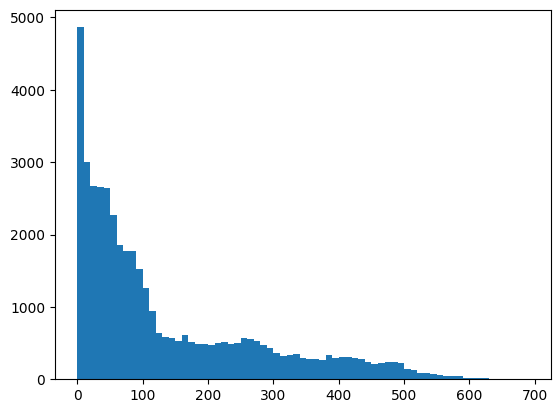

In [156]:
plt.hist(x = df["Total Flow"], bins = np.arange(0, 700, 10))